

**1. Преобразование изображения**
Преобразовал изображение в тензоры цветовых каналов R, G, B.
*Инструменты:* использовал библиотеку `matplotlib`.


Размерность изображения: (640, 800, 3)


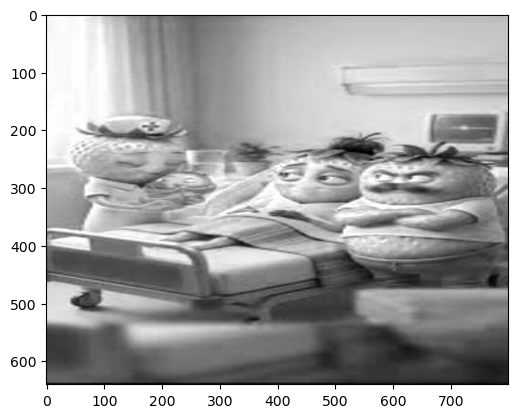

In [9]:
import matplotlib.pyplot as plt
import numpy as np

img = plt.imread('../image/image.jpg')
print("Размерность изображения:", img.shape)
R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]
plt.imshow(R, cmap='gray')
plt.show()


**2. Сингулярное разложение степенным методом.**
Выполнил сингулярное разложение тензоров R, G, B при помощи степенного метода.
**Параметры:**
* Размеры изображения **width, height** задают размер матрицы n*m
* Число итераций: N ∈ {10,50,100}

**Что сделал:**
* Для каждого случая (R,G,B) сравнил результаты при различном числе итераций
* Проверил норму разности исходной матрицы и "воставновленной" из построенного сингулярного разложения:   ∥A − UΣ$V^T$∥

In [10]:
#у нас есть матрица А(ну допустим это R), создаем вектор случайный и ненулевой
#  и приводим матрицу А к квадратному виду
A = R
n, m = A.shape
v0 = np.random.randn(m) #тут используем randn вместо rand
# потому что rand выдает числа только от 0 до 1
#(все координаты стартового вектора (v0) будут строго положительными,
# и вектор всегда будет смотреть только в одну область пространства.) a
# randn использует нормальное распределение(и + и - числа) что для степенного метода
# надежнее так как снижает риск долгой сходимости если настоящий собственный вектор имеет
# отрицательные координаты
spisok = {'R': R,'G':G,'B':B}
for name, color_matrix in spisok.items():
  for N in [10, 50, 100]:
    A = color_matrix.copy()
    k = min(m,n)
    singular_values = []
    u_list = []
    v_list = []
    for i in range(k):
      v0 = np.random.randn(m)
      v_new = A.T @ (A @ v0)
      v_new = v_new / np.linalg.norm(v_new)
      for j in range(N):
        v_new = A.T @ (A @ v_new)
        v_new = v_new / np.linalg.norm(v_new)
      sigma1 = np.linalg.norm(A @ v_new) # используем формулу А*v_new = сигма1 * u
      #u при нормировке слопывается в 1.
      u = A @ v_new / sigma1
      A = A - sigma1 * np.outer(u, v_new)
      singular_values.append(sigma1)
      u_list.append(u)
      v_list.append(v_new)
    U = np.column_stack(u_list)
    V = np.column_stack(v_list)
    Sigma = np.diag(singular_values)
    error = np.linalg.norm(color_matrix - U@Sigma@V.T)
    print(f"Ошибка при N = {N}: {error}")





Ошибка при N = 10: 7.109905647033619e-11
Ошибка при N = 50: 7.247976967874386e-11
Ошибка при N = 100: 7.554953616182299e-11
Ошибка при N = 10: 6.815981524834904e-11
Ошибка при N = 50: 6.23475108267093e-11
Ошибка при N = 100: 6.438670085960795e-11
Ошибка при N = 10: 5.785284918589603e-11
Ошибка при N = 50: 5.801840857231789e-11
Ошибка при N = 100: 6.013272802127131e-11


2. Отрицательных сингулярных чисел не возникло, так как они вычислялись через норму вектора $\|A v\|$, которая строго $\ge 0$. Появление отрицательных чисел означало бы грубую математическую ошибку - путаницу между сингулярными и собственными числами матрицы

## 3. Анализ сингулярных чисел и усеченное SVD

### График зависимости сингулярных чисел от их порядкового номера
Построим график для значений, полученных при $N=100$ (наиболее точных).

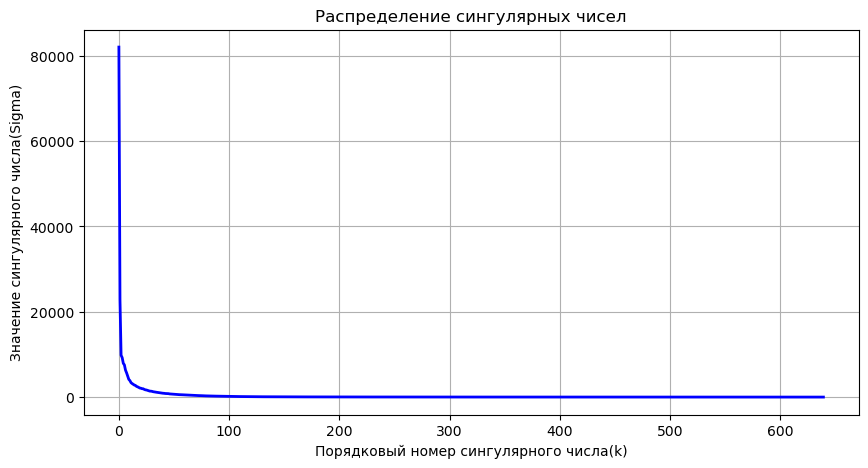

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(singular_values, color = 'blue', linewidth = 2)
plt.title('Распределение сингулярных чисел')
plt.xlabel("Порядковый номер сингулярного числа(k)")
plt.ylabel("Значение сингулярного числа(Sigma)")
plt.grid(True)
plt.show()

### Гипотеза о количестве старших сингулярных чисел
На графике видно типичное распределение: первые несколько десятков сингулярных чисел имеют огромные значения и несут основную информацию изображения. Затем график резко падает и образует длинный хвост из значений, близких к нулю. Этот хвост содержит в основном визуальный шум и мелкие, незначительные детали.

**Предположение:** Для приемлемого визуального качества восстановленного изображения будет достаточно оставить $k = 50$ старших сингулярных чисел. Весь остальной хвост можно отбросить, так как его вклад математически ничтожен.

### Реализация усеченного SVD и визуальная проверка
Формула усеченного разложения:
$$A_k = U_k \Sigma_k V_k^T$$
где $k \ll \min(n, m)$.

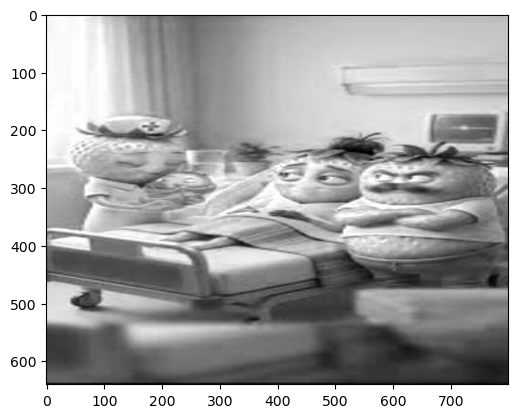

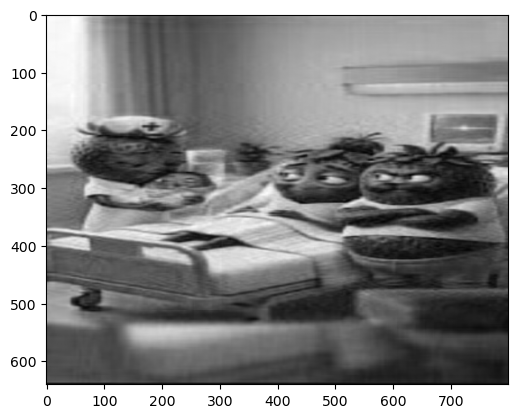

In [12]:
U_new = U[:,:50]
Sigma_new = Sigma[:50,:50]
V_new = V[:,:50].T
A_new = U_new @ Sigma_new @ V_new
plt.imshow(R, cmap='gray')
plt.show()
plt.imshow(A_new, cmap='gray')
plt.show()


## 4. Метод вращений Якоби
В данном разделе мы найдем сингулярные числа для одного из каналов (например, R) альтернативным методом — с помощью вращений Якоби.

### Выбор порога $\epsilon$ и реализация метода
Для остановки итерационного процесса зададим порог точности (tol). Метод будет работать, пока внедиагональные элементы не станут меньше этого порога.
### Сравнение результатов с пунктом 3

[[ 6.80395372e+01  7.36504318e-06  2.21486206e-06  5.33137069e-09
  -6.70102378e-07 -2.87715159e-05 -4.69723767e-07 -5.30886173e-04
   7.66256455e-05 -1.47540486e-05  2.20568314e-07  2.74431118e-11
   1.91173198e-11  6.85099983e-12 -2.33425906e-04]
 [ 7.36503034e-06  1.56650383e-07 -8.04992847e-08 -2.76760096e-05
  -4.50540477e-05 -4.18797813e-08 -2.38689330e-05 -1.91048478e-04
  -7.13689984e-04 -1.03247861e-04 -4.30944933e-06 -1.46609738e-14
  -1.70311053e-14  1.71502392e-14  7.18740012e-11]
 [ 2.21476755e-06 -8.04948877e-08  1.95933554e-06  7.53993304e-04
  -3.78207249e-05  6.99253837e-08  8.89571030e-08  1.97825537e-08
   2.89778229e-18  6.60877848e-04  3.72673931e-04 -2.43427729e-13
  -2.63601942e-13 -8.87978623e-13  1.90830851e-08]
 [ 5.36938106e-09 -2.76760095e-05  7.53993299e-04  4.02784456e-01
  -1.44723018e-15  3.41397950e-05  1.22497043e-07 -5.37859314e-06
   2.27846660e-05  1.16988245e-05 -1.07195260e-04 -2.03788830e-11
  -5.41455825e-11 -4.41263510e-11 -3.94676173e-04]
 [-6

C:\Users\user\AppData\Local\Temp\ipykernel_17060\58298903.py:22: RuntimeWarning: invalid value encountered in sqrt
  singular_values_jacobi = np.sqrt(np.diag(S))# извлекаем диагональ и берем квадратный корень


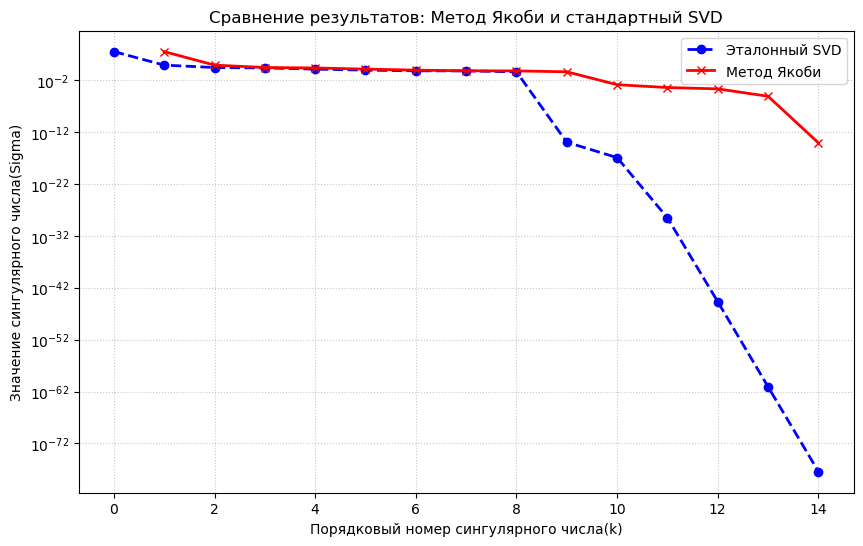

In [13]:
#так как метод Якоби работает исключительно с симметричными матрицами, мы приведем нашу
#исходную матрицу в квадратный вид
A = R[:15, :15].astype("float")
S = A.T @ A
tol = 0.001
#формально это цикл при котором мы делаем иттерации до тех пор, пока макс по модулю
# элемент вне главной диагонали матрицы не станет меньше нашего эпс
while np.max(np.abs(S - np.diag(np.diag(S)))) > tol:
  #берем матрицу где на главноый диаг 0 чтобы найти мак элемент по модулю вне глав диаг
  S_off = np.abs(S - np.diag(np.diag(S)))
  # c помощью данной фукнции мы находим нужные индексы элемента с которым будем работать
  # при работе с вращением Якоби. мы будем применять это к нашей полной ориг матрице
  i,j = np.unravel_index(np.argmax(S_off), S_off.shape)
  theta = 0.5 * np.arctan2(2 * S[i,j],(S[j,j] - S[i,i])) # формула для вычисления угла вращения
  P = np.eye(S.shape[0])
  P[i,i] = P[j,j] = np.cos(theta)
  P[i,j] = np.sin(theta)
  P[j,i] = np.sin(theta) * -1
  S = P.T @ S @ P
print(S)
#4(b) Сравнение результата с пунктом 3
singular_values_jacobi = np.sqrt(np.diag(S))# извлекаем диагональ и берем квадратный корень
#сортируем по убыванию как в стандартном SVD
singular_values_jacobi = np.sort(singular_values_jacobi)[::-1]
print(singular_values_jacobi)
_, sigma_etalon, _ = np.linalg.svd(A)
max_error = np.max(np.abs(singular_values_jacobi - sigma_etalon))
print(f"Максимальная погрешность между методами: {max_error}")

plt.figure(figsize=(10, 6))
plt.plot(sigma_etalon, label = "Эталонный SVD", marker = 'o', linewidth = 2, color = 'blue', linestyle = '--')
plt.plot(singular_values_jacobi, label = "Метод Якоби", marker = 'x',linewidth=2, color='red')
plt.yscale('log')#лог шкала чтобы нижние знач не прилипли к нулю
plt.title('Cравнение результатов: Метод Якоби и стандартный SVD')
plt.xlabel("Порядковый номер сингулярного числа(k)")
plt.ylabel("Значение сингулярного числа(Sigma)")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()












### Сравнение вычислительной сложности (числа операций)
* **Степенной метод:** вычислительная сложность составила $O$($N^2$) на одну итерацию. Это связно с тем, что мы умножаем матрицу на вектор. Это "дешевая" операция.
* **Метод вращений Якоби:** вычислительная сложность составила $O(N^2)$ на один полный проход. Алгоритм требует поиска максимального элемента по всей матрице и так же двойного перемножения полноразмерных матриц $(P^TSP)$ на каждом шаге обнуления определенного элемента.

**5. График распределения яркости по каналам(дополнительно)**
* Построил гистограмму распределения значений пикселей для каждого канала 



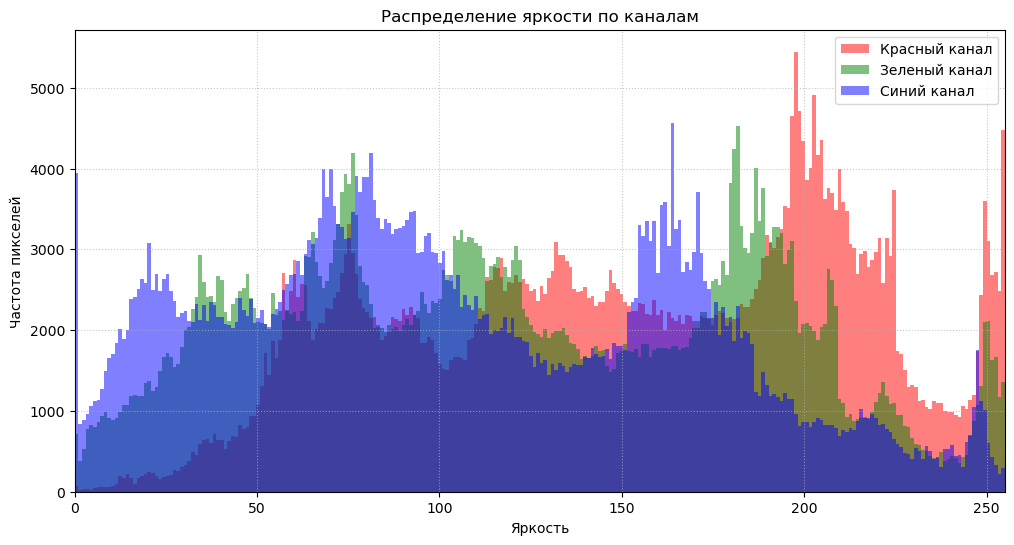

In [14]:
#возьмем наши двумерные матрицы и вытянем их в одномерные списки и скормим матплотлибу :)
r_flat = R.flatten()
g_flat = G.flatten()
b_flat = B.flatten()

plt.figure(figsize=(12, 6))
#bins = 256 потому что для каждого уровня яркости от 0 до 255
plt.hist(r_flat, bins=256, color='red', alpha=0.5, label='Красный канал')
plt.hist(g_flat, bins=256, color='green', alpha=0.5, label='Зеленый канал')
plt.hist(b_flat, bins=256, color='blue', alpha=0.5, label='Синий канал')
plt.title('Распределение яркости по каналам')
plt.xlabel('Яркость')
plt.ylabel('Частота пикселей')
plt.xlim(0,255) # границы гистограммы от 0 до 255
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

**Как сингулярное разложение влияет на распределение яркости в изображении:**
* **Глобальная яркость сохраняется**, самое первое сингулярное число и его векторы хранят в себе заливку или среднюю яркость всего изображения. Поэтому даже при экстремальном сжатии (к = 5 или к = 10) картинка не станет черной или белой. Цвета останутся +- такими же.
* **Ухудшение микроконтраста**. Младшие синг числа(хвост массива) отвечают за мелкие детали и плавные градиенты. При их отсечении плавные переходы пропадают. Визуально это выглядит как пикселизация или полосы на небе(бандинг).

**Свой вариант применения SVD.**
Подавление шума.
Шум - это высокочастотные, абсолютные случайные колебания яркости пикселей. SVD раскладывает информацию по степени важности(от крупных форм к мелким деталям). Основная картина (лица, здания, передний план) - это старшие сингулярные числа, а вот этот мелкий хаотичные шум математически осядет в самом хвосте массива сингулярных чисел. При использовании SVD зашумленной картинки, мы "отрезаем" хвост сингулярных чисел(например оставляем только к = 50 вместо 640) и собираем матрицу обратно по формуле  $A_k = U_k \Sigma_k V_k^T$. Как итог, основная картинка восстанавливается, а шум просто исчезает, так как матрицы, которые его содержали, были нами удалены. Мы получаем математически "сглаженное" изображение.